In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
emails = pd.read_csv('../../data/cleaned/emails_cleaned.csv', low_memory=False)

In [3]:
emails.shape

(123385, 26)

In [4]:
emails.columns

Index(['co_ref', 'crm_accreditation_completed', 'crm_timely_completion',
       'crm_progress_towards_accreditation', 'crm_delays_in_accreditation',
       'crm_contractor_suggested_leave', 'crm_contractor_engagement',
       'crm_contractor_sentiment', 'crm_contractor_sentiment_score',
       'crm_dts_or_ssip_mentioned', 'crm_customer_payment_intention',
       'crm_competitors_mentioned', 'crm_membership_level',
       'crm_platform_issues_raised', 'crm_agent_chased_contractor',
       'crm_agent_chase_count', 'crm_accreditation_issues',
       'crm_membership_overdue', 'crm_auto_renewal_status',
       'crm_dissatisified_with_renewal_price', 'crm_customer_complained',
       'crm_refund_mentioned', 'crm_negative_customer_experience',
       'crm_dissatisfaction_with_support', 'crm_financial_hardship_mentioned',
       'sentiment_category'],
      dtype='str')

In [5]:
emails.head()

,co_ref,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,sentiment_category
0,KG5766,Not Discussed,Not Discussed,Not Discussed,Yes,No,Yes,Neutral,Neutral,No,...,Not Discussed,Yes,No,No,No,Yes,Yes,No,Yes,Neutral
1,EJ1532,Not Discussed,Not Discussed,Not Discussed,No,Not Discussed,No,Not Discussed,Unknown,No,...,Not Discussed,Not Discussed,No,Not Discussed,No,Yes,Yes,No,Not Discussed,Not Discussed
2,AA4063,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Neutral,Neutral,No,...,Not Discussed,No,No,No,No,Yes,Yes,Yes,Not Discussed,Neutral
3,JY9888,No,No,Not Discussed,Yes,No,Yes,Satisfied,Satisfied,Yes,...,Not Discussed,Yes,No,Not Discussed,No,Yes,Yes,No,Not Discussed,Satisfied
4,WO6689,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,Satisfied,Satisfied,No,...,No,No,No,No,No,Yes,Yes,No,Not Discussed,Satisfied


In [6]:
emails.info

<bound method DataFrame.info of         co_ref crm_accreditation_completed crm_timely_completion  \
0       KG5766               Not Discussed         Not Discussed   
1       EJ1532               Not Discussed         Not Discussed   
2       AA4063               Not Discussed         Not Discussed   
3       JY9888                          No                    No   
4       WO6689               Not Discussed         Not Discussed   
...        ...                         ...                   ...   
123380  LY8301               Not Discussed         Not Discussed   
123381  ME4112               Not Discussed         Not Discussed   
123382  QB0417               Not Discussed         Not Discussed   
123383  SM3404               Not Discussed         Not Discussed   
123384  YD6212               Not Discussed         Not Discussed   

       crm_progress_towards_accreditation crm_delays_in_accreditation  \
0                           Not Discussed                         Yes   
1    

In [7]:
emails.describe()

,co_ref,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,...,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,sentiment_category
count,123385,123385,123385,123385,123385,123385,123385,123385,123385,123385,...,123385,123385,123385,123382,123381,123385,123385,123385,123385,123385
unique,37964,4,4,4,8,4,4,5,4,4,...,4,4,4,4,5,22,8,34,10,5
top,BQ8500,No,Not Discussed,Yes,No,No,Yes,Neutral,Neutral,No,...,Not Discussed,Not Discussed,No,Not Discussed,No,No,No,No,Not Discussed,Neutral
freq,8,46191,62515,53393,60825,79369,71127,53577,53573,63654,...,54234,54108,105145,70608,104312,110160,66587,66336,72241,53573


In [8]:
emails.dtypes

co_ref                                  str
crm_accreditation_completed             str
crm_timely_completion                   str
crm_progress_towards_accreditation      str
crm_delays_in_accreditation             str
crm_contractor_suggested_leave          str
crm_contractor_engagement               str
crm_contractor_sentiment                str
crm_contractor_sentiment_score          str
crm_dts_or_ssip_mentioned               str
crm_customer_payment_intention          str
crm_competitors_mentioned               str
crm_membership_level                    str
crm_platform_issues_raised              str
crm_agent_chased_contractor             str
crm_agent_chase_count                   str
crm_accreditation_issues                str
crm_membership_overdue                  str
crm_auto_renewal_status                 str
crm_dissatisified_with_renewal_price    str
crm_customer_complained                 str
crm_refund_mentioned                    str
crm_negative_customer_experience

####    Missing value analysis

In [9]:
missing = emails.isnull().sum()
missing_percent = (missing / len(emails)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

print(missing_df)

                                      Missing Count  Missing %
crm_customer_complained                           4   0.003242
crm_dissatisified_with_renewal_price              3   0.002431
crm_timely_completion                             0   0.000000
crm_progress_towards_accreditation                0   0.000000
crm_delays_in_accreditation                       0   0.000000
crm_contractor_suggested_leave                    0   0.000000
crm_contractor_engagement                         0   0.000000
crm_contractor_sentiment                          0   0.000000
co_ref                                            0   0.000000
crm_accreditation_completed                       0   0.000000
crm_dts_or_ssip_mentioned                         0   0.000000
crm_contractor_sentiment_score                    0   0.000000
crm_customer_payment_intention                    0   0.000000
crm_competitors_mentioned                         0   0.000000
crm_agent_chased_contractor                       0   0

In [10]:
print("Duplicate rows:", emails.duplicated().sum())

Duplicate rows: 387


####    Categorical Column analysis

In [11]:
categorical_column = emails.select_dtypes(include='object').columns
for col in categorical_column:
    print(f"\nValue counts for {col}:")
    print(emails[col].value_counts())


Value counts for co_ref:
co_ref
BQ8500    8
RO5245    8
KY4141    8
QU3166    8
RJ9644    8
         ..
GW8419    1
WD6890    1
DM6279    1
VW5032    1
TP7852    1
Name: count, Length: 37964, dtype: int64

Value counts for crm_accreditation_completed:
crm_accreditation_completed
No               46191
Not Discussed    34870
Yes              21291
Unknown          21033
Name: count, dtype: int64

Value counts for crm_timely_completion:
crm_timely_completion
Not Discussed    62515
No               36986
Unknown          21033
Yes               2851
Name: count, dtype: int64

Value counts for crm_progress_towards_accreditation:
crm_progress_towards_accreditation
Yes              53393
Not Discussed    45953
Unknown          21033
No                3006
Name: count, dtype: int64

Value counts for crm_delays_in_accreditation:
crm_delays_in_accreditation
No                                                                                                                            60825
Yes   

C:\Users\AtharvaRana\AppData\Local\Temp\ipykernel_16164\760693980.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_column = emails.select_dtypes(include='object').columns


crm_dissatisfaction_with_support
No                                                                                                                                                                                            66336
Not Discussed                                                                                                                                                                                 34818
Unknown                                                                                                                                                                                       11475
Yes                                                                                                                                                                                           10723
indicating a potential issue with the accreditation process."                                                                                                                          



Value counts for crm_financial_hardship_mentioned:
crm_financial_hardship_mentioned
Not Discussed                                                                                                                                   72241
No                                                                                                                                              33120
Unknown                                                                                                                                         11475
Yes                                                                                                                                              6515
Yes                                                                                                                                                29
 city is required"" message."                                                                                                                       1
[Yes/No/Not Di

In [12]:
cat_cols = emails.select_dtypes(include=['object', 'category']).columns
cat_cols=cat_cols.drop('co_ref')
print("Categorical Columns:", cat_cols)

Categorical Columns: Index(['crm_accreditation_completed', 'crm_timely_completion',
       'crm_progress_towards_accreditation', 'crm_delays_in_accreditation',
       'crm_contractor_suggested_leave', 'crm_contractor_engagement',
       'crm_contractor_sentiment', 'crm_contractor_sentiment_score',
       'crm_dts_or_ssip_mentioned', 'crm_customer_payment_intention',
       'crm_competitors_mentioned', 'crm_membership_level',
       'crm_platform_issues_raised', 'crm_agent_chased_contractor',
       'crm_agent_chase_count', 'crm_accreditation_issues',
       'crm_membership_overdue', 'crm_auto_renewal_status',
       'crm_dissatisified_with_renewal_price', 'crm_customer_complained',
       'crm_refund_mentioned', 'crm_negative_customer_experience',
       'crm_dissatisfaction_with_support', 'crm_financial_hardship_mentioned',
       'sentiment_category'],
      dtype='str')


C:\Users\AtharvaRana\AppData\Local\Temp\ipykernel_16164\3105560454.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = emails.select_dtypes(include=['object', 'category']).columns



Top values in crm_accreditation_completed:
crm_accreditation_completed
No               46191
Not Discussed    34870
Yes              21291
Unknown          21033
Name: count, dtype: int64


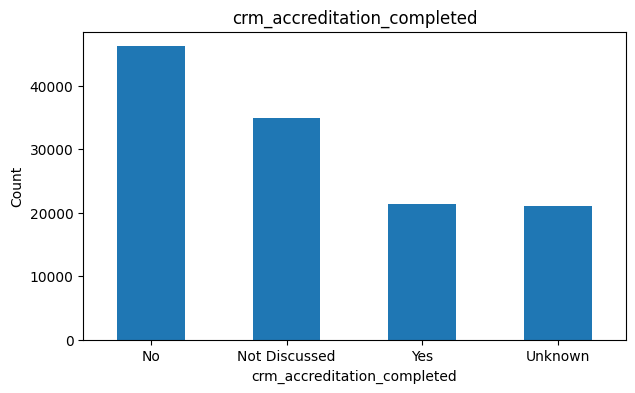


Top values in crm_timely_completion:
crm_timely_completion
Not Discussed    62515
No               36986
Unknown          21033
Yes               2851
Name: count, dtype: int64


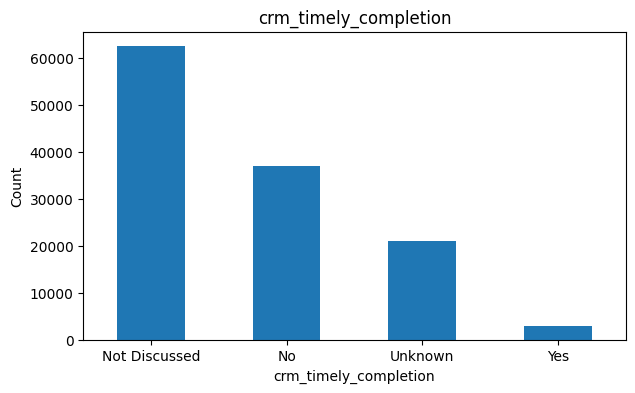


Top values in crm_progress_towards_accreditation:
crm_progress_towards_accreditation
Yes              53393
Not Discussed    45953
Unknown          21033
No                3006
Name: count, dtype: int64


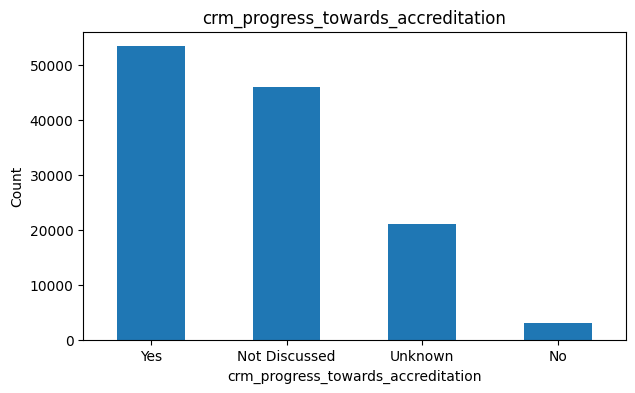


Top values in crm_delays_in_accreditation:
crm_delays_in_accreditation
No                                                                                                                            60825
Yes                                                                                                                           40319
Unknown                                                                                                                       21033
Not Discussed                                                                                                                  1204
Not Discussed is not applicable here, so I will default to: No                                                                    1
Not Discussed but potentially yes as the customer is trying to contact Ian and was told he may be in later or the next day        1
Not Discussed is not applicable here as there is no information about accreditation delays, so the correct answer is: No          1
Not 

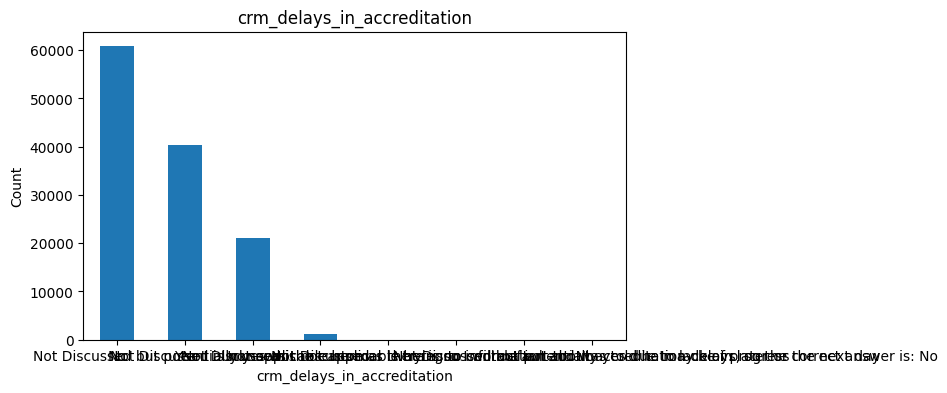


Top values in crm_contractor_suggested_leave:
crm_contractor_suggested_leave
No               79369
Unknown          21033
Not Discussed    14289
Yes               8694
Name: count, dtype: int64


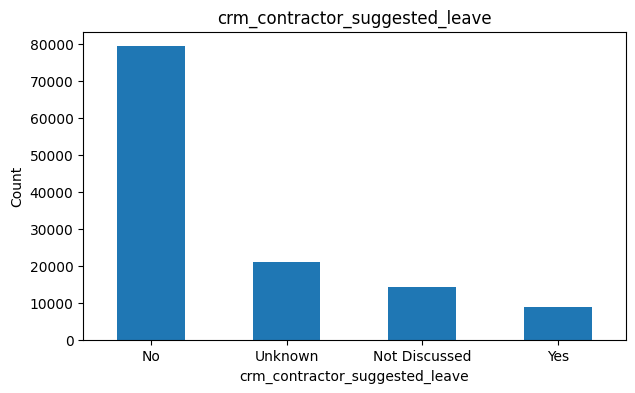


Top values in crm_contractor_engagement:
crm_contractor_engagement
Yes              71127
No               31197
Unknown          21050
Not Discussed       11
Name: count, dtype: int64


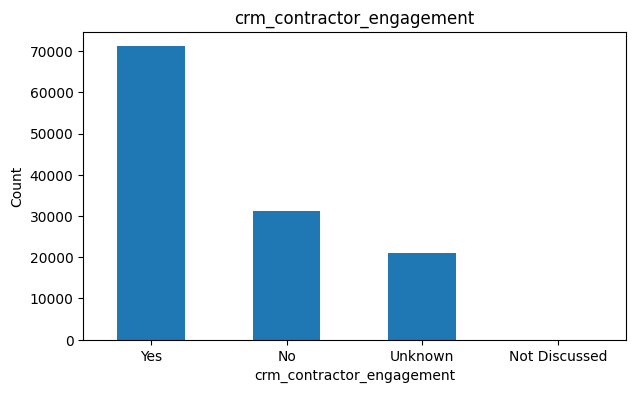


Top values in crm_contractor_sentiment:
crm_contractor_sentiment
Neutral          53577
Not Discussed    31167
Unknown          21037
Satisfied        11405
Dissatisfied      6199
Name: count, dtype: int64


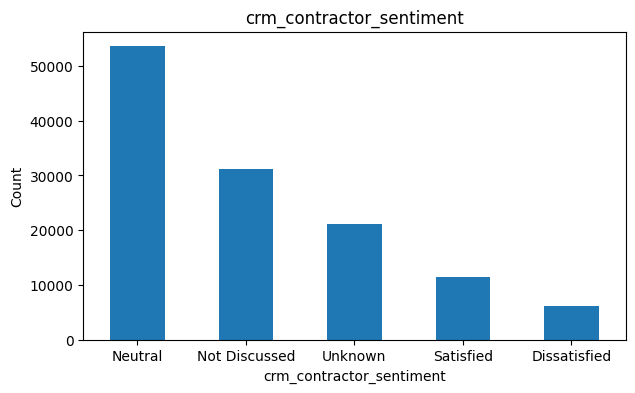


Top values in crm_contractor_sentiment_score:
crm_contractor_sentiment_score
Neutral         53573
Unknown         52228
Satisfied       11413
Dissatisfied     6171
Name: count, dtype: int64


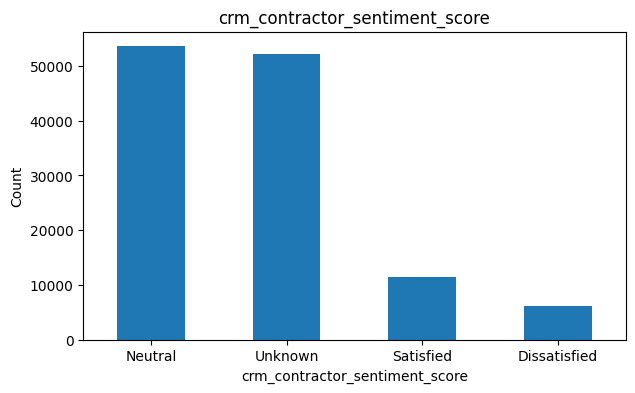


Top values in crm_dts_or_ssip_mentioned:
crm_dts_or_ssip_mentioned
No               63654
Yes              38696
Unknown          21033
Not Discussed        2
Name: count, dtype: int64


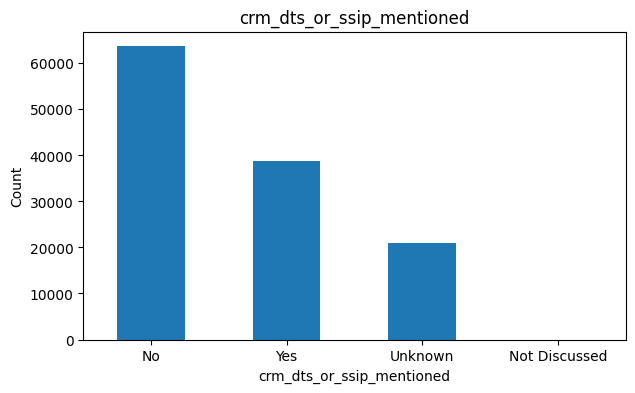


Top values in crm_customer_payment_intention:
crm_customer_payment_intention
Not Discussed    69475
Yes              28235
Unknown          21033
No                4640
20                   1
30                   1
Name: count, dtype: int64


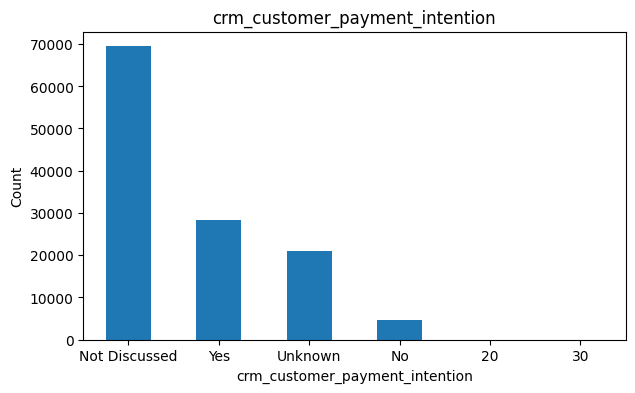


Top values in crm_competitors_mentioned:
crm_competitors_mentioned
No                                           79547
Not Discussed                                26955
Unknown                                      11155
Yes                                           5724
Yes (Avetta is mentioned as a competitor)        3
Yes (Avetta mentioned as a competitor)           1
Name: count, dtype: int64


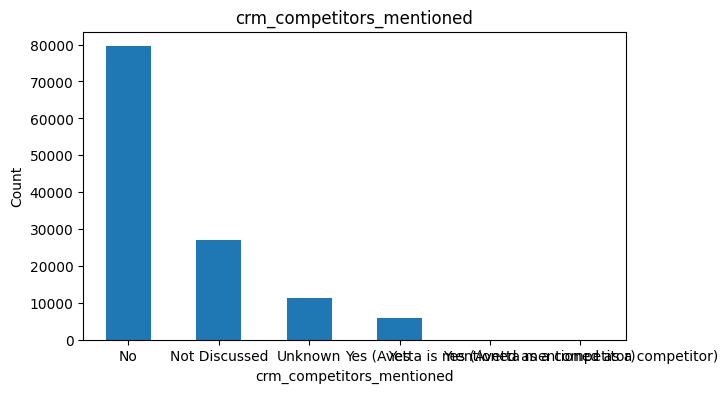


Top values in crm_membership_level:
crm_membership_level
In progress       45217
Accredited        35850
Not Discussed     29889
Unknown           11155
Members only        854
Standard            173
Not Accredited      104
In Progress          23
Silver               17
Gold                 13
Name: count, dtype: int64


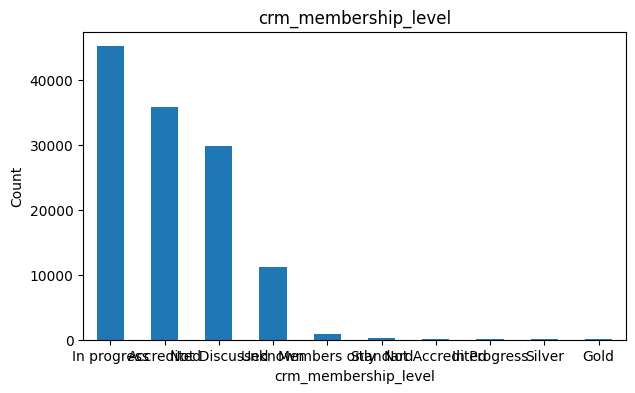


Top values in crm_platform_issues_raised:
crm_platform_issues_raised
No               84963
Not Discussed    19945
Unknown          11155
Yes               7322
Name: count, dtype: int64


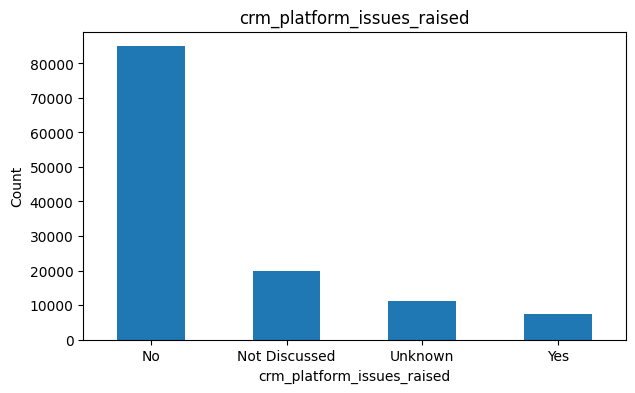


Top values in crm_agent_chased_contractor:


crm_agent_chased_contractor
Yes              75029
No               36708
Unknown          11155
Not Discussed      493
Name: count, dtype: int64


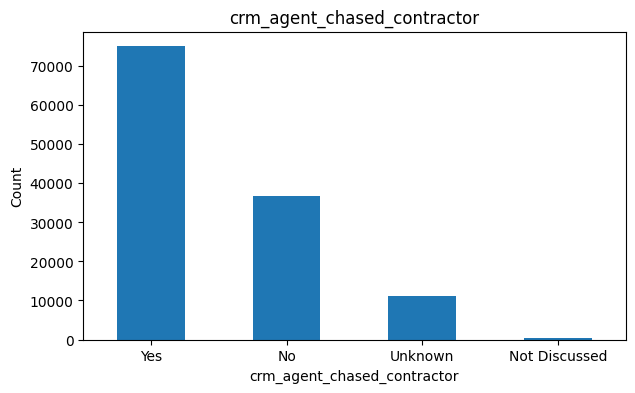


Top values in crm_agent_chase_count:
crm_agent_chase_count
Low        68458
Medium     38969
Unknown    11234
High        4724
Name: count, dtype: int64


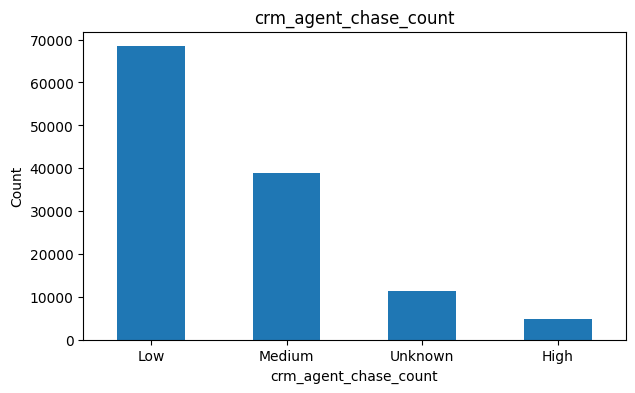


Top values in crm_accreditation_issues:
crm_accreditation_issues
Not Discussed    54234
Yes              44785
No               13211
Unknown          11155
Name: count, dtype: int64


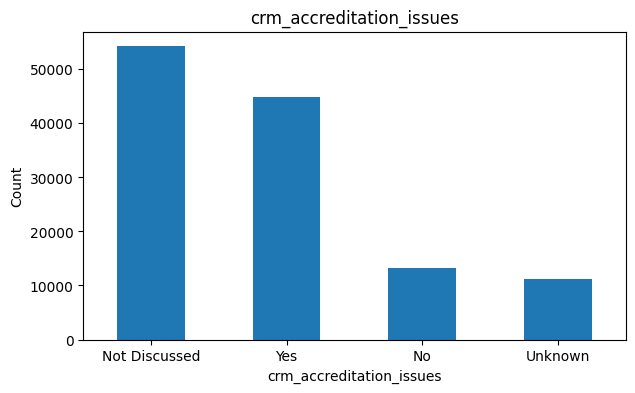


Top values in crm_membership_overdue:
crm_membership_overdue
Not Discussed    54108
Yes              30136
No               27936
Unknown          11205
Name: count, dtype: int64


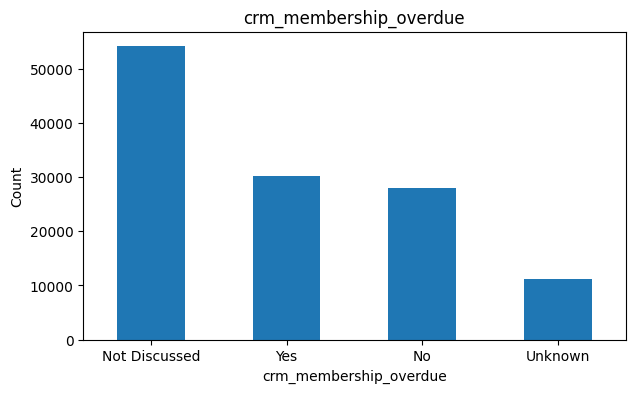


Top values in crm_auto_renewal_status:
crm_auto_renewal_status
No               105145
Unknown           15865
Yes                2355
Not Discussed        20
Name: count, dtype: int64


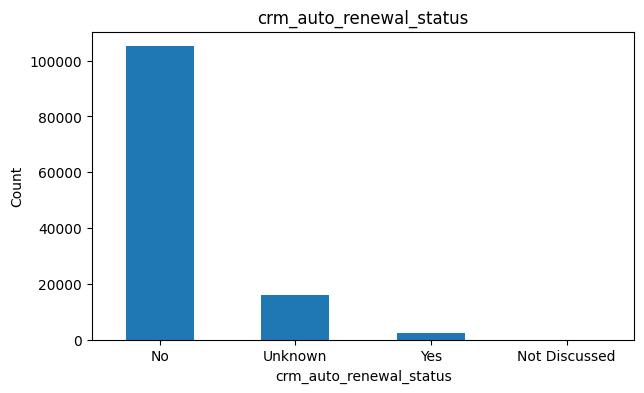


Top values in crm_dissatisified_with_renewal_price:
crm_dissatisified_with_renewal_price
Not Discussed    70608
No               33100
Unknown          11155
Yes               8519
Name: count, dtype: int64


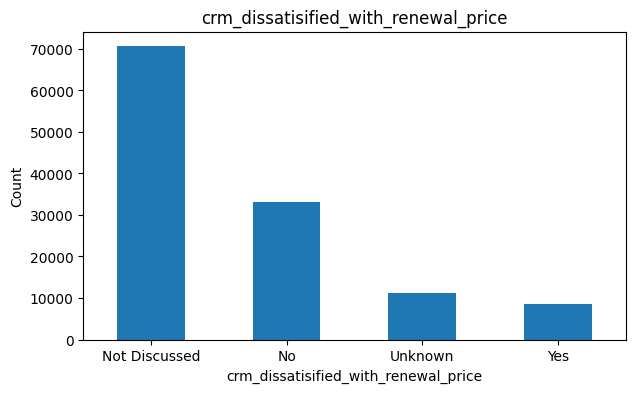


Top values in crm_customer_complained:
crm_customer_complained
No                104312
Unknown            11475
Yes                 7568
Not Discussed         16
Not Applicable        10
Name: count, dtype: int64


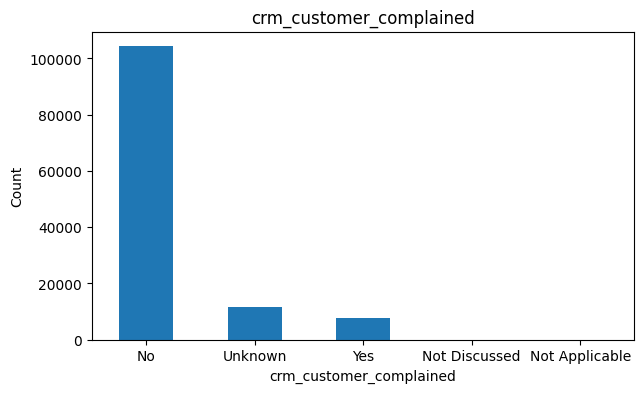


Top values in crm_refund_mentioned:
crm_refund_mentioned
No                                                               110160
Unknown                                                           11475
Yes                                                                1704
Not Discussed                                                        27
Not Applicable                                                        2
feeling it implied their evidence was not legitimate                  1
which provides laundry services for top London hotels."               1
which would dramatically affect their business."                      1
and the additional cost for expedited review."                        1
despite their accreditation and insurances being up to date."         1
Name: count, dtype: int64


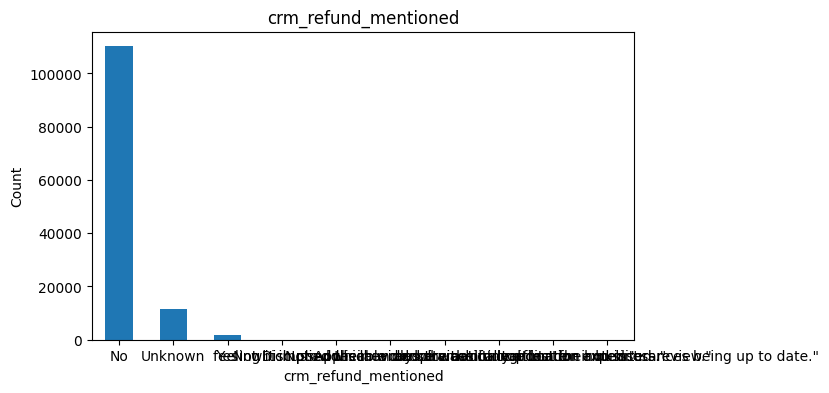


Top values in crm_negative_customer_experience:
crm_negative_customer_experience
No                                                       66587
Not Discussed                                            26962
Yes                                                      18357
Unknown                                                  11475
 and also expressed concerns about the audit process         1
[Yes/No/Not Discussed]                                       1
 causing them to lose work."                                 1
Not applicable (there is no email content to analyze)        1
Name: count, dtype: int64


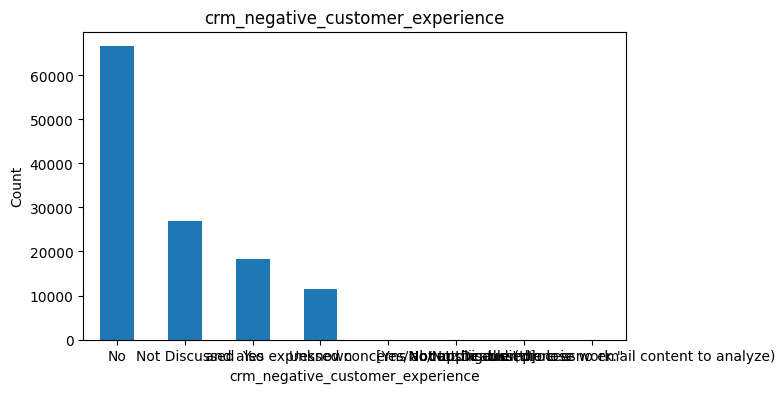


Top values in crm_dissatisfaction_with_support:
crm_dissatisfaction_with_support
No                                                                        66336
Not Discussed                                                             34818
Unknown                                                                   11475
Yes                                                                       10723
indicating a potential issue with the accreditation process."                 3
indicating a sense of urgency and frustration."                               2
"" which may impact their eligibility for projects."                          1
invalid address                                                               1
which led to a last-minute and urgent request to resolve the payment."        1
causing confusion and concern."                                               1
Name: count, dtype: int64


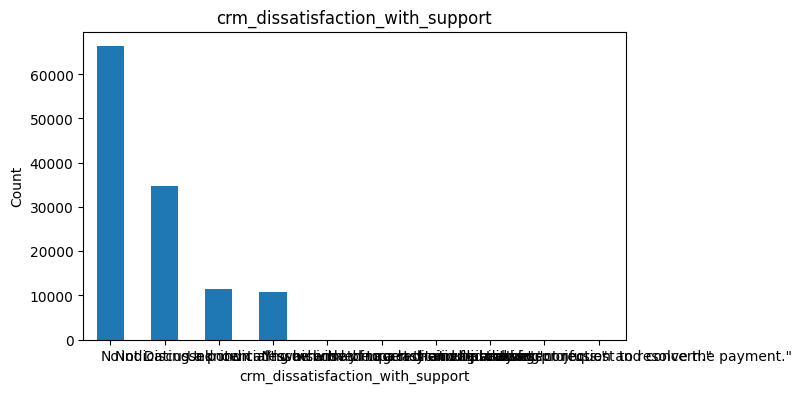


Top values in crm_financial_hardship_mentioned:
crm_financial_hardship_mentioned
Not Discussed                                                                                                                                   72241
No                                                                                                                                              33120
Unknown                                                                                                                                         11475
Yes                                                                                                                                              6515
Yes                                                                                                                                                29
 city is required"" message."                                                                                                                       1
[Yes/No/Not Discus

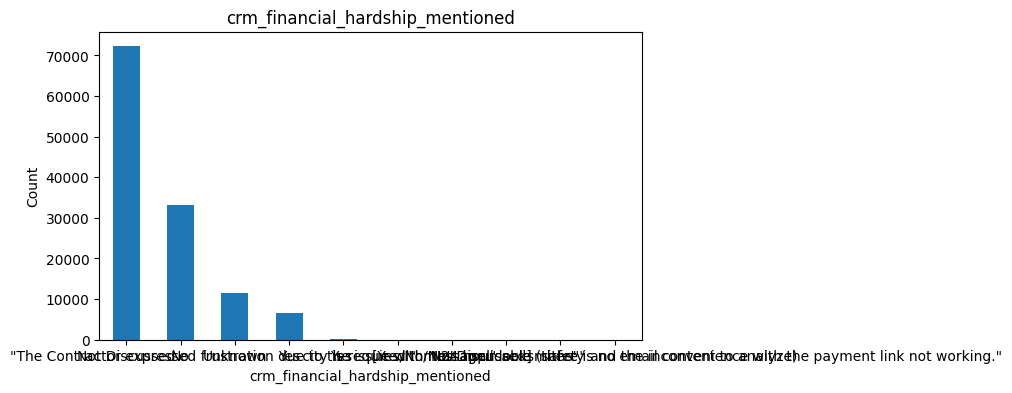


Top values in sentiment_category:
sentiment_category
Neutral          53573
Not Discussed    31167
Unknown          21061
Satisfied        11413
Dissatisfied      6171
Name: count, dtype: int64


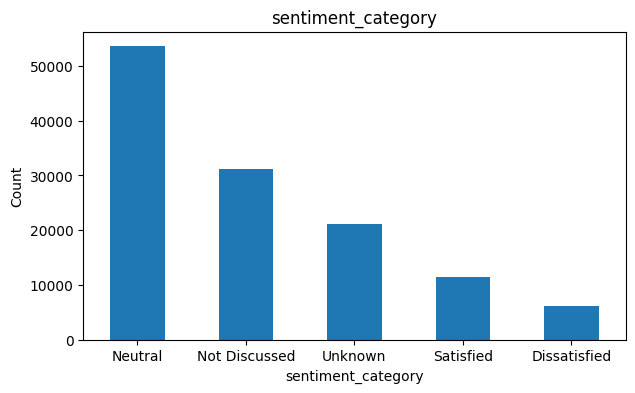

In [13]:
for col in cat_cols:
    print(f"\nTop values in {col}:")
    print(emails[col].value_counts().head(10))
    
    plt.figure(figsize=(7,4))
    emails[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()